/tmp/ipykernel_4176/2802022211.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')


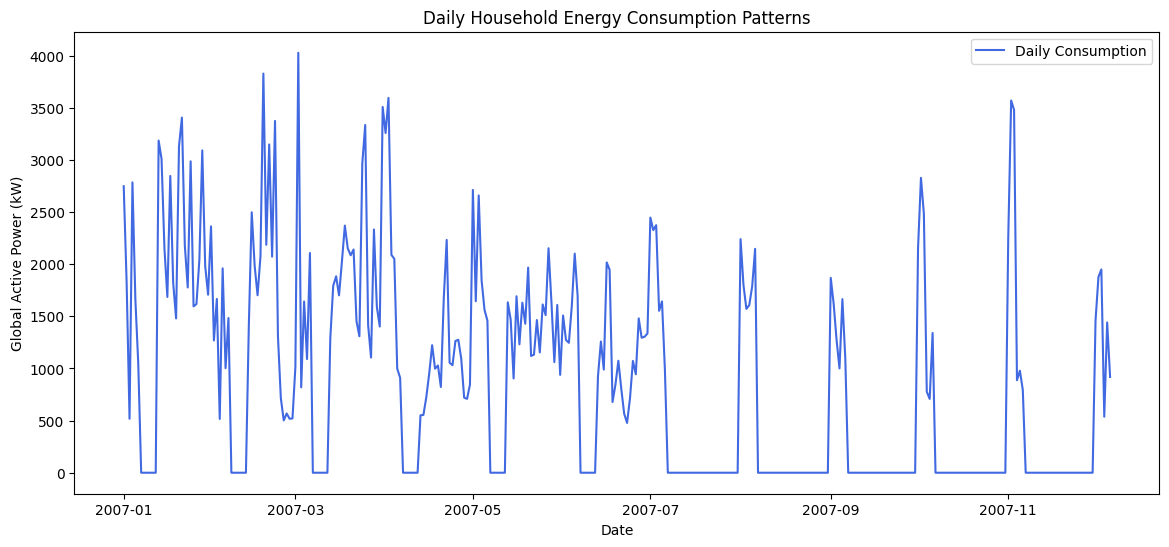

XGBoost -> MAE: 448.31, RMSE: 990.23
ARIMA -> MAE: 447.81, RMSE: 990.65


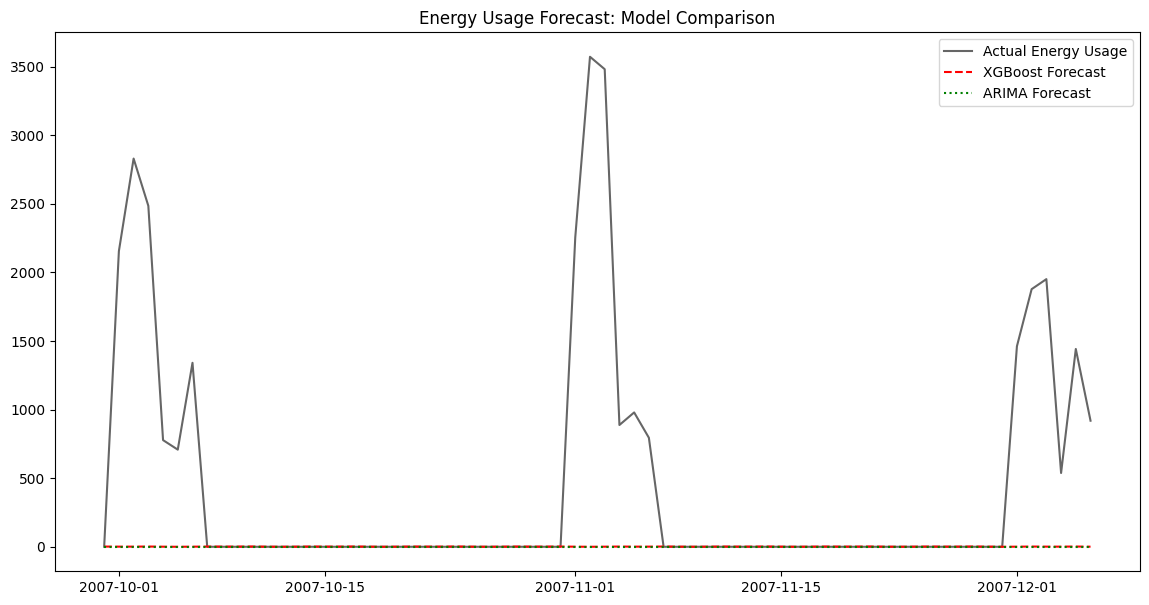

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

# Load the Household Power Consumption Dataset
df = pd.read_csv('household_power_consumption.csv')

# 1. Combine Date and Time into a single Datetime object
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')
df = df.dropna(subset=['Datetime'])

# 2. Convert 'Global_active_power' to numeric (handling '?' as NaN)
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')
df = df.ffill() # Forward fill missing values

# 3. Set Datetime as index
df.set_index('Datetime', inplace=True)

# 4. Resample the data to Daily frequency (Sum of energy used per day)
# This makes the time series patterns easier to identify and model
daily_data = df['Global_active_power'].resample('D').sum().to_frame()

# --- [Step 3: Feature Engineering] ---
# Engineering time-based features for XGBoost
daily_data['day_of_week'] = daily_data.index.dayofweek
daily_data['month'] = daily_data.index.month
daily_data['day_of_year'] = daily_data.index.dayofyear
daily_data['is_weekend'] = daily_data.index.dayofweek.isin([5, 6]).astype(int)

# --- [Step 4: Exploratory Data Analysis (EDA)] ---
plt.figure(figsize=(14, 6))
plt.plot(daily_data['Global_active_power'], color='royalblue', label='Daily Consumption')
plt.title('Daily Household Energy Consumption Patterns')
plt.xlabel('Date')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.show()

# --- [Step 5: Model Building and Comparison] ---
# Split data into Train and Test sets
train_size = int(len(daily_data) * 0.8)
train, test = daily_data.iloc[:train_size], daily_data.iloc[train_size:]

# 1. XGBoost Model
X_train = train.drop('Global_active_power', axis=1)
y_train = train['Global_active_power']
X_test = test.drop('Global_active_power', axis=1)
y_test = test['Global_active_power']

xgb_model = XGBRegressor(n_estimators=1000, learning_rate=0.05)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

# 2. ARIMA Model (Statistical)
# We use simple parameters (5,1,0) for demonstration; in practice, use auto_arima
arima_model = ARIMA(train['Global_active_power'], order=(5, 1, 0))
arima_fit = arima_model.fit()
arima_preds = arima_fit.forecast(steps=len(test))

# --- [Step 6: Evaluation and Visualization] ---
def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{model_name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}")

evaluate(y_test, xgb_preds, "XGBoost")
evaluate(y_test, arima_preds, "ARIMA")

# Visualizing Actual vs Forecasted
plt.figure(figsize=(14, 7))
plt.plot(test.index, y_test, label='Actual Energy Usage', color='black', alpha=0.6)
plt.plot(test.index, xgb_preds, label='XGBoost Forecast', color='red', linestyle='--')
plt.plot(test.index, arima_preds, label='ARIMA Forecast', color='green', linestyle=':')
plt.title('Energy Usage Forecast: Model Comparison')
plt.legend()
plt.show()